# Problem 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [2]:
# Read CSV file
chick = pd.read_csv("chickwts.csv")

In [3]:
# Problem 1. (a)
# How many instances and variables are in this data set?
# How do you get this information without viewing data?

print(chick.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   weight  71 non-null     int64 
 1   feed    71 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.2+ KB
None


In [4]:
# Problem 1. (b)
# (b)	The column “weight” means weights in grams.
# Add a “new” column that gives the weight in kilograms, rather than grams.
# Make sure the column has a descriptive name.
chick["weightkg"] = chick.weight / 1000
print(chick.head())

   weight       feed  weightkg
0     179  horsebean     0.179
1     160  horsebean     0.160
2     136  horsebean     0.136
3     227  horsebean     0.227
4     217  horsebean     0.217


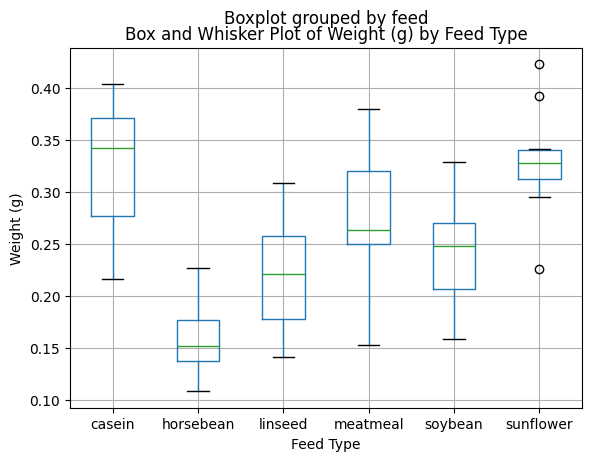

In [5]:
# Problem 1. (c)
# Make a box-and-whiskers plot showing the distribution of chicken weight according to feed type.
# Make sure to label the axes appropriately.

chick.boxplot(column="weightkg", by="feed")
plt.title("Box and Whisker Plot of Weight (g) by Feed Type")
plt.xlabel("Feed Type")
plt.ylabel("Weight (g)")
plt.show()

# Problem 2

In [6]:
# Read CSV file
clin = pd.read_csv("OVCclinicalinfo.csv")

print(clin.head())

  OVC TumorID  Survival  0 = alive   1 = dead  Assigned Stage GRADE Debulk  \
0        0.08        14                     1             4.0     3      S   
1         860        17                     1             4.0     3      O   
2         872       185                     0             3.0     3      S   
3         922       183                     0             3.0     2      S   
4        1024        13                     1             4.0     3      S   

  CA125.POST  response 0=NR, 1=CR   
0       72.3                     0  
1        133                     0  
2        3.1                     1  
3          9                     1  
4         12                     1  


In [7]:
# Problem 2. (a)
# Summarize the distribution of each variable in this data set.

# Numerical
print(clin.describe())

# Categorical
print(clin.describe(include='object'))

         Survival  0 = alive   1 = dead  Assigned Stage  response 0=NR, 1=CR 
count  119.000000            119.000000      118.000000            119.000000
mean    49.268908              0.579832        3.152542              0.714286
std     41.403492              0.495673        0.384021              0.453664
min      1.000000              0.000000        2.000000              0.000000
25%     16.000000              0.000000        3.000000              0.000000
50%     34.000000              1.000000        3.000000              1.000000
75%     74.000000              1.000000        3.000000              1.000000
max    185.000000              1.000000        4.000000              1.000000
       OVC TumorID GRADE Debulk CA125.POST
count          119   118    119        114
unique         119     7      5         86
top           0.08     3      S          7
freq             1    55     49          7


In [8]:
# Problem 2. (b) - i
#Remove the variable “Survival” from this data set.

clin = clin.drop(columns=["Survival"])

clin.head()

,OVC TumorID,0 = alive 1 = dead,Assigned Stage,GRADE,Debulk,CA125.POST,"response 0=NR, 1=CR"
0,0.08,1,4.0,3,S,72.3,0
1,860,1,4.0,3,O,133,0
2,872,0,3.0,3,S,3.1,1
3,922,0,3.0,2,S,9,1
4,1024,1,4.0,3,S,12,1


In [9]:
# Problem 2. (b) - ii
# Convert the first column to character type.

first_col = clin.columns[0]
clin[first_col] = clin[first_col].astype("string")

print(clin[first_col].head())

0    0.08
1     860
2     872
3     922
4    1024
Name: OVC TumorID, dtype: string


In [10]:
# Problem 2. (b) - iii
# Change the name of the third column to “event”.

third_col = clin.columns[2]
clin = clin.rename(columns= {third_col: "event"})

clin.head()

,OVC TumorID,0 = alive 1 = dead,event,GRADE,Debulk,CA125.POST,"response 0=NR, 1=CR"
0,0.08,1,4.0,3,S,72.3,0
1,860,1,4.0,3,O,133,0
2,872,0,3.0,3,S,3.1,1
3,922,0,3.0,2,S,9,1
4,1024,1,4.0,3,S,12,1


In [11]:
# Problem 2. (b) - iv
# Convert the “CA125.POST” and “GRADE” columns into numeric values, with the ambiguous entries coded as NAs.

clin["CA125.POST"] = pd.to_numeric(clin["CA125.POST"], errors="coerce")
clin["GRADE"] = pd.to_numeric(clin["GRADE"], errors="coerce")

clin.iloc[26]

,26
OVC TumorID,2064
0 = alive 1 = dead,1
event,3.0
GRADE,3.0
Debulk,O
CA125.POST,NaN
"response 0=NR, 1=CR",0


In [12]:
# Problem 2. (b) - v
# Fix the “Debulk” column such that only two levels are used (“O” and “S”).

deb = (
        clin["Debulk"]
        .astype("string")
        .str.strip()
        .str.upper()
        .str[0]  # Argument to take first letter (handles "Optimal"and "Suboptimal" entries)
    )
clin["Debulk"] = deb.where(deb.isin(["O", "S"]))

clin.head(100)

,OVC TumorID,0 = alive 1 = dead,event,GRADE,Debulk,CA125.POST,"response 0=NR, 1=CR"
0,0.08,1,4.0,3.0,S,72.3,0
1,860,1,4.0,3.0,O,133.0,0
2,872,0,3.0,3.0,S,3.1,1
3,922,0,3.0,2.0,S,9.0,1
4,1024,1,4.0,3.0,S,12.0,1
...,...,...,...,...,...,...,...
95,M1572,1,3.0,3.0,O,49.0,0
96,M17,0,4.0,2.0,S,4700.0,0
97,M1891,0,4.0,1.0,S,17.0,1
98,M2070,0,3.0,3.0,S,22.0,1


In [13]:
# Problem 2. (b) - vi
# Rename the eighth column to “response” and convert it to a binary variable (0 = FALSE, 1 = TRUE)

eighth_col = clin.columns[6]
clin = clin.rename(columns={eighth_col: "response"})

clin["response"] = (
    pd.to_numeric(clin["response"], errors="coerce")
      .where(lambda s: s.isin([0, 1]))
      .astype("UInt8")
)

clin.head(5)

,OVC TumorID,0 = alive 1 = dead,event,GRADE,Debulk,CA125.POST,response
0,0.08,1,4.0,3.0,S,72.3,0
1,860,1,4.0,3.0,O,133.0,0
2,872,0,3.0,3.0,S,3.1,1
3,922,0,3.0,2.0,S,9.0,1
4,1024,1,4.0,3.0,S,12.0,1


In [14]:
# Problem 2. (c)
# Is there any missing values or outliers in this data set?
print(clin.isna().sum())

OVC TumorID              0
0 = alive   1 = dead     0
event                    1
GRADE                    5
Debulk                   0
CA125.POST              11
response                 0
dtype: int64


# Problem 3

In [15]:
# Understanding the data before it is cleaned
# [BAD] is the target and a binary flag with no missing entries

data = pd.read_csv("hmeq.csv")

summary = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "non_null": data.notna().sum(),
    "missing": data.isna().sum(),
    "missing_%": (100 * data.isna().mean()).round(2),
    "unique": data.nunique(dropna=True)
})
summary

,dtype,non_null,missing,missing_%,unique
BAD,int64,5960,0,0.00,2
LOAN,int64,5960,0,0.00,540
MORTDUE,float64,5442,518,8.69,5053
VALUE,float64,5848,112,1.88,5381
REASON,object,5708,252,4.23,2
JOB,object,5681,279,4.68,6
YOJ,float64,5445,515,8.64,99
DEROG,float64,5252,708,11.88,11
DELINQ,float64,5380,580,9.73,14
CLAGE,float64,5652,308,5.17,5314


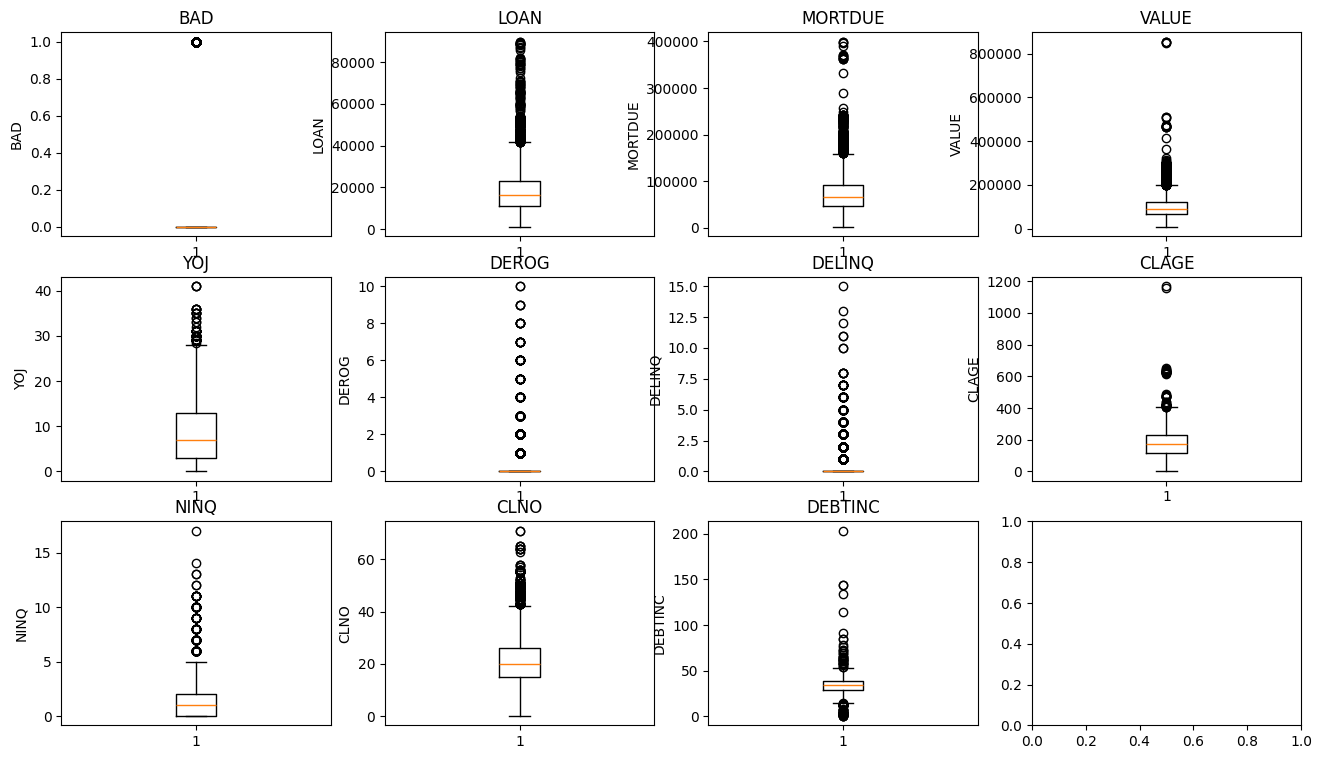

In [16]:
#Visualizing Distributions Before Data Cleaning
num_cols = data.select_dtypes(include="number").columns

cols_per_row = 4
n_cols = cols_per_row
n_rows = math.ceil(len(num_cols) / cols_per_row)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(data[col].dropna())
    axes[i].set_title(f"{col}")
    axes[i].set_ylabel(col)

plt.show()



In [17]:
# Data Cleaning and Outlier Handling Function

# 1) Define column groups because only continuous data will be included in this moderate outlier analisys
count_like = [c for c in ["DEROG","DELINQ","NINQ","CLNO","BAD"] if c in data.columns]
num_cols   = data.select_dtypes(include="number").columns.tolist()
cont_cols  = [c for c in num_cols if c not in count_like]   # continuous only

# 2) Outlier flag (IQR with looser fence k=3.0.)
# We were orliginally looking at the usual IQR rule of k=1.5 but that led to too many entries being dropped
def is_outlier_iqr(s: pd.Series, k: float = 3.0) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        return pd.Series(False, index=s.index)
    low, high = q1 - k*iqr, q3 + k*iqr
    return (s < low) | (s > high)

# 3) Drop rows that are outliers in any continuous column
flags = pd.DataFrame({c: is_outlier_iqr(data[c], k=3.0) for c in cont_cols})
keep_mask = ~flags.any(axis=1)
clean_drop = data[keep_mask].copy()
print(f"Dropped rows: {len(data) - len(clean_drop)} ")

# 4) Replace missing values
#   We are using the median for numeric values
for c in cont_cols:
    clean_drop[c] = clean_drop[c].fillna(clean_drop[c].median())

#    And the mode for count like values that display mostly 0s
for c in count_like:
    if c in clean_drop.columns:
        clean_drop[c] = clean_drop[c].fillna(0)

#    For categoricals (Reason & Job) we are going with the mode
cat_cols = clean_drop.select_dtypes(exclude="number").columns
for c in cat_cols:
    m = clean_drop[c].mode(dropna=True)
    if not m.empty:
        clean_drop[c] = clean_drop[c].fillna(m.iloc[0])

Dropped rows: 206 


In [18]:
# Assessing the data before it is cleaned
summary = pd.DataFrame({
    "dtype": clean_drop.dtypes.astype(str),
    "non_null": clean_drop.notna().sum(),
    "missing": clean_drop.isna().sum(),
    "missing_%": (100 * clean_drop.isna().mean()).round(2),
    "unique": clean_drop.nunique(dropna=True)
})
summary

,dtype,non_null,missing,missing_%,unique
BAD,int64,5754,0,0.0,2
LOAN,int64,5754,0,0.0,479
MORTDUE,float64,5754,0,0.0,4857
VALUE,float64,5754,0,0.0,5185
REASON,object,5754,0,0.0,2
JOB,object,5754,0,0.0,6
YOJ,float64,5754,0,0.0,99
DEROG,float64,5754,0,0.0,11
DELINQ,float64,5754,0,0.0,14
CLAGE,float64,5754,0,0.0,5125


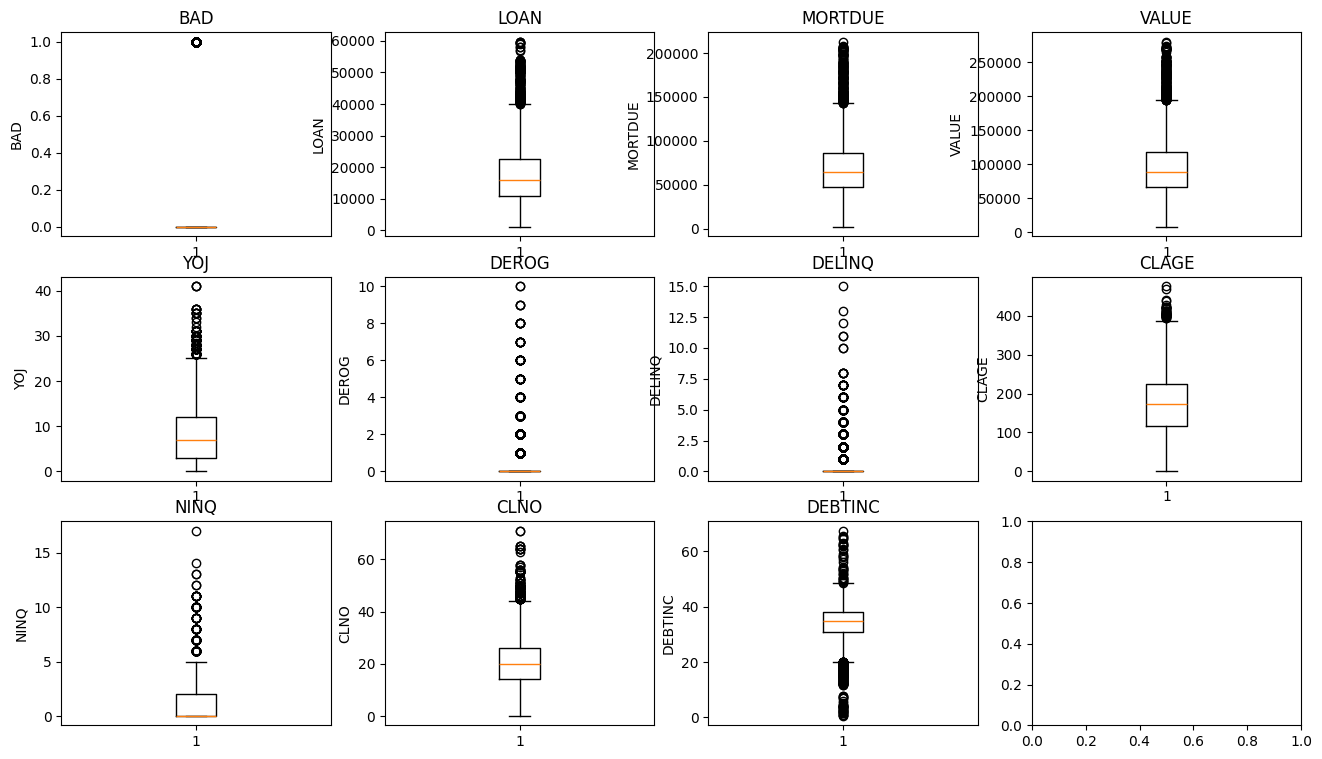

In [19]:
#Visualizing Distributions After Data Cleaning
num_cols = clean_drop.select_dtypes(include="number").columns

cols_per_row = 4
n_cols = cols_per_row
n_rows = math.ceil(len(num_cols) / cols_per_row)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(clean_drop[col].dropna())
    axes[i].set_title(f"{col}")
    axes[i].set_ylabel(col)

plt.show()


# Problem 4

In [20]:
# Problem 4. (1)
# Split the data into two subsets: training (70%) and test (30%)

from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = clean_drop.drop(columns=["BAD"])
y = clean_drop["BAD"]

# Split into train (70%) and test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(len(X_train))
print(len(X_test))


4027
1727


In [21]:
# Problem 4. (2)
# Ensure that the target variable BAD is a flag variable.
# This was already confirmed by the above summary statement in Problem 3,
# which returned that column BAD has no missing values and only 2 unique values.

valid = set(clean_drop["BAD"].unique()) <= {0, 1}
if valid:
        print("BAD is a binary flag.")
else:
        print("BAD contains values outside 0  and 1.")

BAD is a binary flag.


Tree depth: 22
Number of leaves: 388


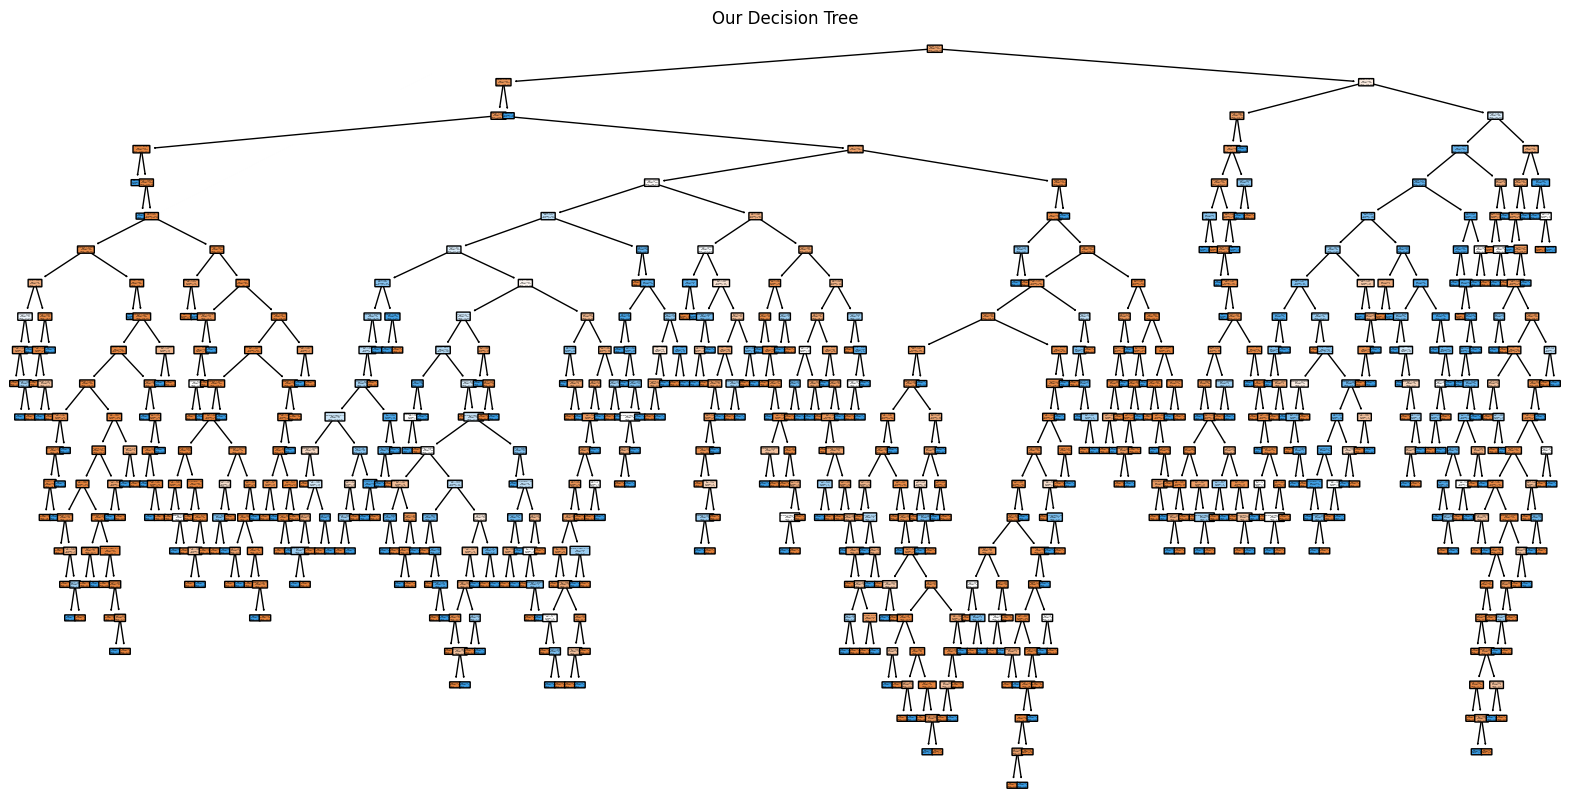

Default Model Performance:
Accuracy: 0.8686
ROC-AUC: 0.7738

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1385
           1       0.69      0.62      0.65       342

    accuracy                           0.87      1727
   macro avg       0.80      0.77      0.78      1727
weighted avg       0.86      0.87      0.87      1727


5. Decision tree rules (first 20 rules):
|--- DELINQ <= 0.50
|   |--- DEBTINC <= 45.94
|   |   |--- DEBTINC <= 34.76
|   |   |   |--- VALUE <= 20765.50
|   |   |   |   |--- class: 1
|   |   |   |--- VALUE >  20765.50
|   |   |   |   |--- LOAN <= 2250.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- LOAN >  2250.00
|   |   |   |   |   |--- YOJ <= 5.50
|   |   |   |   |   |   |--- MORTDUE <= 37346.50
|   |   |   |   |   |   |   |--- LOAN <= 13800.00
|   |   |   |   |   |   |   |   |--- VALUE <= 37409.50
|   |   |   |   |   |   |   |   |   |--- DEBTINC <= 29.96
|   |   |   | 

In [22]:
# Problem 4. (3)

# Then build the decision tree and check the prediction result using the default settings,
# and take a look at the tree by printing the rules and plotting the tree. Explain and discuss the rules and plot briefly.

# Default Decision tree

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Encoding categoricals into dummy variables
X_train_encoded = pd.get_dummies(X_train, columns=['REASON', 'JOB'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['REASON', 'JOB'], drop_first=True)

# Training the default tree (gini criterion)
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_encoded, y_train)

# Accessing the decision rules by examining the tree structure
print("Tree depth:", dt_default.get_depth())
print("Number of leaves:", dt_default.get_n_leaves())

# Predicted Probabilities and Classes
y_pred_default = dt_default.predict(X_test_encoded)
y_pred_proba_default = dt_default.predict_proba(X_test_encoded)[:, 1]
tree_pred_class = dt_default.predict(X_test_encoded)

# Plot Default Tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_default,
    feature_names=X_train_encoded.columns,
    class_names=['No', 'Yes'],  # Assuming 0 = No, 1 = Yes
    filled=True,
    rounded=True
)
plt.title("Our Decision Tree")
plt.show()

print("Default Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_default):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_default):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_default))

print("\n5. Decision tree rules (first 20 rules):")
# Use the encoded feature names for the tree export
tree_rules = export_text(dt_default, feature_names=list(X_train_encoded.columns))
rules_lines = tree_rules.split('\n')
for i, rule in enumerate(rules_lines[:20]):
    if rule.strip():
        print(rule)
if len(rules_lines) > 20:
    print(f"... and {len(rules_lines) - 20} more rules")

Tuned Model Performance:
Accuracy: 0.8651
ROC-AUC: 0.8636

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1385
           1       0.85      0.39      0.53       342

    accuracy                           0.87      1727
   macro avg       0.86      0.68      0.73      1727
weighted avg       0.86      0.87      0.84      1727



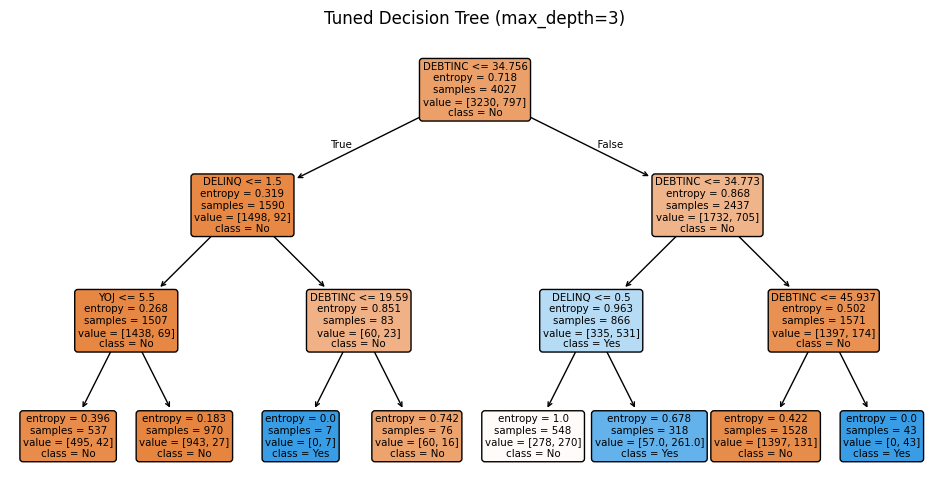

In [23]:
# Problem 4. (4)
# Manipulate the default setting by changing the parameters, and try to improve the performance.
# Justify your choice.

# Tuned Decision Tree
dt_tuned = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=None,
    random_state=42
)
dt_tuned.fit(X_train_encoded, y_train)

# Predictions
y_pred_tuned = dt_tuned.predict(X_test_encoded)
y_pred_proba_tuned = dt_tuned.predict_proba(X_test_encoded)[:, 1]

# Performance
print("Tuned Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

# Plot tuned tree
plt.figure(figsize=(12, 6))
plot_tree(
    dt_tuned,
    feature_names=X_train_encoded.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True
)
plt.title("Tuned Decision Tree (max_depth=3)")
plt.show()


In [24]:
# Problem 4. (5)
# Get default feature importances
importances = dt_default.feature_importances_
features = X_train_encoded.columns

feat_importance_df = pd.DataFrame({
    'Feature': features,
    'Default Importance': importances
}).sort_values(by='Default Importance', ascending=False)

print(feat_importance_df)


           Feature  Default Importance
9          DEBTINC            0.344999
5           DELINQ            0.121997
6            CLAGE            0.085850
0             LOAN            0.079011
8             CLNO            0.077751
1          MORTDUE            0.069487
3              YOJ            0.061025
2            VALUE            0.058084
7             NINQ            0.035910
4            DEROG            0.029491
10  REASON_HomeImp            0.008576
15        JOB_Self            0.007749
11      JOB_Office            0.006537
13     JOB_ProfExe            0.006225
14       JOB_Sales            0.004245
12       JOB_Other            0.003063


In [25]:
# Problem 4. (5)
# Get tuned feature importances
importances = dt_tuned.feature_importances_
features = X_train_encoded.columns

tunedfeat_importance_df = pd.DataFrame({
    'Feature': features,
    'Tuned Importance': importances
}).sort_values(by='Tuned Importance', ascending=False)

print(tunedfeat_importance_df)

           Feature  Tuned Importance
9          DEBTINC          0.887947
5           DELINQ          0.098791
3              YOJ          0.013262
1          MORTDUE          0.000000
2            VALUE          0.000000
4            DEROG          0.000000
6            CLAGE          0.000000
0             LOAN          0.000000
7             NINQ          0.000000
8             CLNO          0.000000
10  REASON_HomeImp          0.000000
11      JOB_Office          0.000000
12       JOB_Other          0.000000
13     JOB_ProfExe          0.000000
14       JOB_Sales          0.000000
15        JOB_Self          0.000000
